# Midterm: Detecting Malicious Network Traffic Using Machine Learning

Keith Walker
ITAI 1371

# Project Overview

This project explores whether machine learning can classify network traffic as benign or malicious. The goal is to compare multiple machine learning models and determine which one performs best for detecting DNS-based distributed "denial of service" attack traffic (DrDoS DNS). The dataset used in this project comes from the CICDDoS2019 dataset and includes both benign and malicious traffic records.

# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# 2. Load Dataset

The dataset used in this project is the DrDoS_DNS.csv file from the CICDDoS2019 dataset.

In [ ]:
import pandas as pd

data = pd.read_csv("DrDoS_DNS.csv", low_memory=False, nrows=50000)
data.head()

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,425,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,2018-12-01 10:51:39.813448,28415,97,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_DNS
1,430,172.16.0.5-192.168.50.1-60495-634-17,192.168.50.1,634,172.16.0.5,60495,17,2018-12-01 10:51:39.820842,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,DrDoS_DNS
2,1654,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,2018-12-01 10:51:39.852499,48549,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_DNS
3,2927,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,2018-12-01 10:51:39.890213,48337,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_DNS
4,694,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,2018-12-01 10:51:39.941151,32026,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_DNS


# 3. Explore Dataset

This section checks the size of the dataset, column names, and label distribution.

In [ ]:
print("Dataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns.tolist())

Dataset Shape: (50000, 88)

Column Names:
['Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Le

In [ ]:
data.columns = data.columns.str.strip()
print(data["Label"].value_counts())

Label
DrDoS_DNS    48298
BENIGN        1702
Name: count, dtype: int64


# 4. Data Preprocessing

The data was cleaned by removing extra spaces in column names, converting labels to binary values, dropping non-numeric identifier columns, and replacing infinite or missing values.

In [ ]:
data["Label"] = data["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

X = data.drop("Label", axis=1)
y = data["Label"]

X = X.drop(columns=["Flow ID", "Source IP", "Destination IP", "Timestamp", "SimillarHTTP"], errors="ignore")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print(X.dtypes)

Unnamed: 0            int64
Source Port           int64
Destination Port      int64
Protocol              int64
Flow Duration         int64
                     ...   
Idle Mean           float64
Idle Std            float64
Idle Max            float64
Idle Min            float64
Inbound               int64
Length: 82, dtype: object


# 5. Split Data Into Training and Testing Sets

The dataset was split into training and testing sets using an 80/20 ratio.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (40000, 82)
Testing Set Shape: (10000, 82)


# 6. Random Forest Model

Random Forest was selected because prior research shows that it performs well for intrusion detection tasks and can handle complex feature relationships.

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       330
           1       1.00      1.00      1.00      9670

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# 7. Random Forest Confusion Matrix

The confusion matrix shows how well the Random Forest model classified benign and malicious traffic.

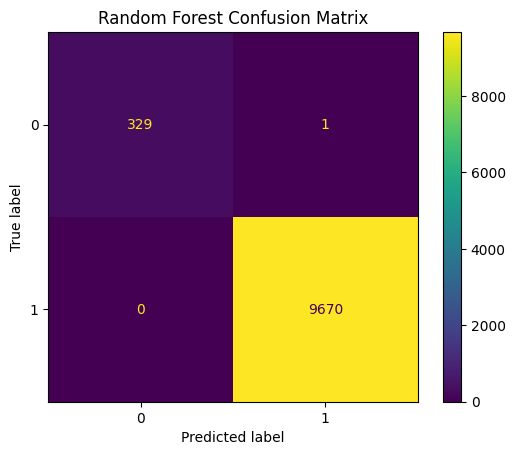

In [ ]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

# 8. Logistic Regression Model

Logistic Regression was selected as a baseline model for binary classification.

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.988
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       330
           1       0.99      0.99      0.99      9670

    accuracy                           0.99     10000
   macro avg       0.90      0.91      0.91     10000
weighted avg       0.99      0.99      0.99     10000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 9. Decision Tree Model

Decision Tree was selected because it is easy to interpret and commonly used in classification problems.

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       330
           1       1.00      1.00      1.00      9670

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# 10. K-Nearest Neighbors Model

KNN was selected to compare a distance-based classification method with the other models.

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9971
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       330
           1       1.00      1.00      1.00      9670

    accuracy                           1.00     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       1.00      1.00      1.00     10000



# 11. Model Comparison

The following table compares the accuracy of the four models tested in this project.

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "Decision Tree", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ]
})

results

,Model,Accuracy
0,Random Forest,0.9999
1,Logistic Regression,0.9880
2,Decision Tree,0.9998
3,KNN,0.9971


# 12. Discussion

All four models performed well, but Random Forest produced the best overall results, which matches prior intrusion detection research. One limitation is that the dataset was highly imbalanced and only included DrDoS DNS traffic, so the accuracy may appear higher than it would on a more balanced dataset.

# 13. Conclusion

This project showed that machine learning can be used to tell the difference between benign and malicious network traffic. Four models were tested, and Random Forest gave the best results.

I also learned that cleaning and preparing the dataset is an important step before training the models. In the future, this project could be improved by using more types of attacks and a more balanced dataset.